In [1]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split

from model_torch import DIPAutoencoder1D


from utils import yc_patch, remove_columns_kurtosis

In [2]:

fig_path = "./figs/FORGE/"
model_path = "./model/"
data_path = "./data/"
os.makedirs(fig_path, exist_ok=True)
os.makedirs(model_path, exist_ok=True)

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Data shape (original): (960, 2000)


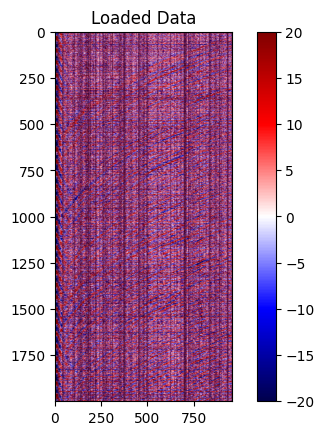

In [3]:
eq_num = 36
data_name = f"eq-{eq_num}"
w1, w2 = 24, 24
z1, z2 = 6, 6
batch_size = 1024
drop_rate = 0.2

# Load and display data
data = np.load(f"{data_path}{data_name}.npy")
print("Data shape (original):", data.shape)
data = data.T

plt.figure()
plt.imshow(data, cmap="seismic", vmin=-20, vmax=20)
plt.title("Loaded Data")
plt.colorbar()
plt.show()

In [4]:
data_noise = yc_patch(data, w1, w2, z1, z2)
data_noise_selected = remove_columns_kurtosis(data_noise, drop_rate)

print("Data shape after patching:", data_noise.shape)
print("Data shape after patch selection:", data_noise_selected.shape)

# float32 is standard for PyTorch/GPU training.
x = torch.from_numpy(np.asarray(data_noise_selected, dtype=np.float32))
dataset = TensorDataset(x, x)

# Match Keras validation_split=0.1.
n_val = max(1, int(round(0.1 * len(dataset))))
n_train = len(dataset) - n_val
generator = torch.Generator().manual_seed(seed)
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=generator)

train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False,
    pin_memory=torch.cuda.is_available()
)


Data shape after patching: (51967, 576)
Data shape after patch selection: (41573, 576)


In [5]:
D1 = 128
D2 = D1 // 4
D3 = D2 // 4
kernel_size = 3
input_size = data_noise.shape[1]  # 24*24 = 576

model = DIPAutoencoder1D(
    input_size=input_size,
    d1=D1,
    d2=D2,
    d3=D3,
    kernel_size=kernel_size,
).to(device)

print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# Same optimizer/loss choices as Keras notebook.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()


DIPAutoencoder1D(
  (enc1): ConvBranchBlock(
    (main): Sequential(
      (0): Conv1d(576, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): PReLU(num_parameters=128)
    )
    (alt_pad): ConstantPad1d(padding=(2, 3), value=0.0)
    (alt_conv): Conv1d(576, 128, kernel_size=(6,), stride=(1,))
    (alt_prelu): PReLU(num_parameters=128)
    (mix): Conv1d(256, 128, kernel_size=(1,), stride=(1,))
    (mix_prelu): PReLU(num_parameters=128)
  )
  (att1): ECABlock(
    (conv1): Conv1d(128, 1, kernel_size=(1,), stride=(1,), bias=False)
    (relu): ReLU()
    (conv2): Conv1d(1, 1, kernel_size=(1,), stride=(1,), bias=False)
    (sigmoid): Sigmoid()
  )
  (enc2): ConvBranchBlock(
    (main): Sequential(
      (0): Conv1d(128, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2):

In [6]:
epochs = 50
patience = 5
best_train_loss = float("inf")
best_state = None
wait = 0

ckpt_path = os.path.join(
    model_path,
    f"FORGE_model_{data_name}_p{w1}_s{z1}_drop_{drop_rate}_ep{epochs}.pt",
)

history = {"loss": [], "val_loss": []}
start_time = time.time()

for epoch in range(1, epochs + 1):
    model.train()
    train_loss_sum = 0.0
    train_count = 0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        bs = xb.size(0)
        train_loss_sum += loss.item() * bs
        train_count += bs

    train_loss = train_loss_sum / train_count

    model.eval()
    val_loss_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            bs = xb.size(0)
            val_loss_sum += loss.item() * bs
            val_count += bs

    val_loss = val_loss_sum / val_count
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch:03d}/{epochs} | "
        f"loss={train_loss:.6e} | val_loss={val_loss:.6e}"
    )

    # Original callbacks monitor training loss, not validation loss.
    if train_loss < best_train_loss:
        best_train_loss = train_loss
        best_state = copy.deepcopy(model.state_dict())
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": best_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": train_loss,
                "input_size": input_size,
                "D1": D1,
                "D2": D2,
                "D3": D3,
            },
            ckpt_path,
        )
        print(f"  Saved best checkpoint -> {ckpt_path}")
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping after {patience} epochs without training-loss improvement.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print(f"Training time for FORGE data: {time.time() - start_time:.4f} seconds")

Epoch 001/50 | loss=4.685926e+02 | val_loss=3.654115e+02
  Saved best checkpoint -> ./model/FORGE_model_eq-36_p24_s6_drop_0.2_ep50.pt
Epoch 002/50 | loss=3.190444e+02 | val_loss=2.758066e+02
  Saved best checkpoint -> ./model/FORGE_model_eq-36_p24_s6_drop_0.2_ep50.pt
Epoch 003/50 | loss=2.524595e+02 | val_loss=2.298746e+02
  Saved best checkpoint -> ./model/FORGE_model_eq-36_p24_s6_drop_0.2_ep50.pt
Epoch 004/50 | loss=2.189528e+02 | val_loss=2.090651e+02
  Saved best checkpoint -> ./model/FORGE_model_eq-36_p24_s6_drop_0.2_ep50.pt
Epoch 005/50 | loss=2.028505e+02 | val_loss=1.976660e+02
  Saved best checkpoint -> ./model/FORGE_model_eq-36_p24_s6_drop_0.2_ep50.pt
Epoch 006/50 | loss=1.942107e+02 | val_loss=1.906746e+02
  Saved best checkpoint -> ./model/FORGE_model_eq-36_p24_s6_drop_0.2_ep50.pt
Epoch 007/50 | loss=1.877297e+02 | val_loss=1.853803e+02
  Saved best checkpoint -> ./model/FORGE_model_eq-36_p24_s6_drop_0.2_ep50.pt
Epoch 008/50 | loss=1.837392e+02 | val_loss=1.835303e+02
  Sav

In [7]:
model.eval()
with torch.no_grad():
    restored_selected = model(x.to(device)).cpu().numpy()

print("Restored selected patches shape:", restored_selected.shape)

Restored selected patches shape: (41573, 576)
